# Chapter 6 - Arrangements

## Source Span

This notebook covers **Computational Geometry in C**, Chapter 6, printed pages 193-219: arrangements of lines and planes, combinatorial counts, the zone theorem, incremental construction, higher-dimensional arrangements, point-line duality, higher-order Voronoi diagrams, and applications such as visibility graphs, hidden-surface removal, aspect graphs, smallest shadows, ham-sandwich cuts, red-blue matching, centerpoints, and minimum-area triangles. The source chapter is intentionally abstract; this notebook makes the abstraction visible with small executable models.

An arrangement of lines partitions the plane into vertices, edges, and faces. In a simple arrangement of `n` lines, every pair intersects once and no three lines meet at a point, so the counts are fixed: `V = C(n,2)`, `E = n^2`, and `F = C(n,2)+n+1`. Degeneracies such as parallel lines or triple intersections only reduce those counts; small perturbations increase them back toward the simple maximum. The zone theorem is the algorithmic heart of the chapter: the total number of edges bounding the cells crossed by one inserted line is only linear in `n`, with the source giving the bound `Zn < 6n`. That makes incremental construction quadratic overall.

The chapter then turns arrangements into a unifying language. Duality maps points to lines and changes incidence/order questions into level questions. Median levels encode bisectors for ham-sandwich cuts. Higher-order Voronoi diagrams can be viewed as levels in arrangements. Visibility, graphics, shadows, and matching all use the same partition-and-search idea.


## Visual Storyboard

1. **Simple arrangement board.** Draw six nonparallel, nonconcurrent lines, compute all intersections, and verify `V`, `E`, and `F` formulas.
2. **Degeneracy perturbation.** Compare a triple-intersection/parallel example with a perturbed simple arrangement to show why degeneracy lowers complexity.
3. **Zone traversal.** Insert a horizontal line, mark crossed cells along it, and record a linear zone-edge ledger below the `6n` theorem bound.
4. **Incremental construction cost.** Sum per-insertion zone bounds to show how a linear zone bound yields `O(n^2)` construction.
5. **Duality and ham-sandwich levels.** Dualize two separated point sets, plot median-level samples, and locate an approximate simultaneous bisector.
6. **Application map.** Save a table connecting arrangements to visibility, hidden-surface removal, aspect graphs, shadows, higher-order Voronoi diagrams, red-blue matching, centerpoints, and minimum-area triangle searches.


## Library Routing

`numpy` carries line/intersection arithmetic, `matplotlib` draws arrangements and level plots, and `networkx` draws the application dependency map. The notebook uses formulas and synthetic examples rather than a full planar subdivision implementation, because the source chapter itself focuses on combinatorial structure more than C code. The checks therefore emphasize counts, perturbation effects, zone bounds, duality consistency, and application coverage.


In [1]:
# setup
from __future__ import annotations
import json, math, sys
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

BOOK_ROOT = Path.cwd()
while not ((BOOK_ROOT / "AGENTS.md").exists() and (BOOK_ROOT / "source_map.json").exists()):
    if BOOK_ROOT.parent == BOOK_ROOT:
        raise RuntimeError("Could not locate Computational-Geometry-in-C root")
    BOOK_ROOT = BOOK_ROOT.parent
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-06-arrangements"
UNIT_TITLE = "Arrangements"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

storyboard = [
    {"move": "simple arrangement", "visual": "simple-line-arrangement-counts.png", "check": "simple_counts_match_formula"},
    {"move": "degeneracy perturbation", "visual": "degeneracy-perturbation.png", "check": "perturbation_increases_vertices"},
    {"move": "zone theorem", "visual": "zone-traversal-bound.png", "check": "zone_ledger_below_six_n"},
    {"move": "incremental construction", "visual": "incremental-zone-costs.png", "check": "incremental_total_is_quadratic_scale"},
    {"move": "duality levels", "visual": "duality-median-levels.png", "check": "median_levels_intersect_once_in_window"},
    {"move": "applications", "visual": "arrangement-application-map.png", "check": "application_map_covers_source_examples"},
]
routing_rows = [
    {"source_topic": "line arrangements and V/E/F counts", "artifact": "simple-line-arrangement-counts.png", "code_cell": "arrangement counts"},
    {"source_topic": "simple vs nonsimple arrangements", "artifact": "degeneracy-perturbation.png", "code_cell": "degeneracy perturbation"},
    {"source_topic": "zone theorem and insertion", "artifact": "zone-traversal-bound.png", "code_cell": "zone theorem"},
    {"source_topic": "incremental construction algorithm", "artifact": "incremental-zone-costs.png", "code_cell": "incremental costs"},
    {"source_topic": "duality, levels, ham-sandwich cuts", "artifact": "duality-median-levels.png", "code_cell": "median levels"},
    {"source_topic": "applications", "artifact": "arrangement-application-map.png", "code_cell": "application map"},
]
storyboard_path = save_json({"unit": UNIT_TITLE, "source_span": "printed pages 193-219", "storyboard": storyboard}, CHECKS / "visual-storyboard.json")
routing_path = save_csv(routing_rows, TABLES / "library-routing.csv")
coverage_path = save_json({
    "unit": UNIT_TITLE,
    "source_span": {"printed_pages": "193-219", "pdf_pages": "202-228"},
    "covered_ideas": [
        "arrangements partition the plane into vertices, edges, and faces",
        "simple arrangement counts and nonsimple degeneracy perturbation",
        "zone theorem with linear bound Zn < 6n",
        "incremental arrangement construction by walking the inserted line's zone",
        "arrangements of planes and higher-dimensional complexity",
        "point-line duality, levels, and higher-order Voronoi diagrams",
        "applications: visibility, hidden-surface removal, aspect graphs, shadows, ham-sandwich cuts, red-blue matching, centerpoints, minimum-area triangles",
    ],
}, CHECKS / "source-coverage.json")
print(json.dumps({"artifact_root": str(ARTIFACT_ROOT), "storyboard_items": len(storyboard)}, indent=2))


{
  "artifact_root": "D:\\Geometry\\Computational-Geometry-in-C\\artifacts\\chapter-06-arrangements",
  "storyboard_items": 6
}


## Simple Arrangements and Counts

In a simple arrangement, no two lines are parallel and no three lines meet at one point. That assumption forces uniform counts. Each pair of lines gives one vertex, inserting the `n`th line creates `n` new edges on the inserted line and splits existing edges, and the unbounded Euler variant gives the face count. The figure shows a bounded window, but the counts are for the full arrangement, including unbounded edges and faces outside the plotted rectangle.


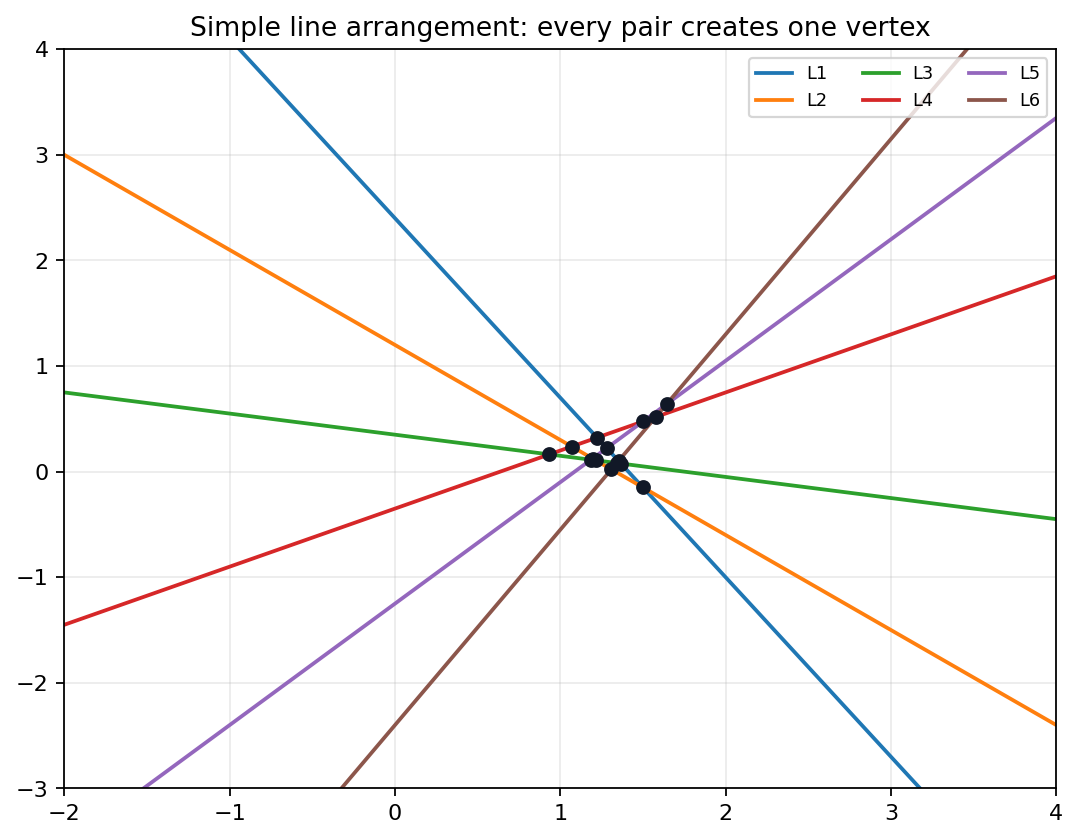

{
  "V": 15,
  "E": 36,
  "F": 22
}


In [2]:
lines = [
    {"name": "L1", "m": -1.7, "b": 2.4},
    {"name": "L2", "m": -0.9, "b": 1.2},
    {"name": "L3", "m": -0.2, "b": 0.35},
    {"name": "L4", "m": 0.55, "b": -0.35},
    {"name": "L5", "m": 1.15, "b": -1.25},
    {"name": "L6", "m": 1.85, "b": -2.4},
]

def intersect(l1, l2):
    x = (l2["b"] - l1["b"]) / (l1["m"] - l2["m"])
    y = l1["m"] * x + l1["b"]
    return np.array([x, y])

intersections = []
for i, j in combinations(range(len(lines)), 2):
    p = intersect(lines[i], lines[j])
    intersections.append({"line_a": lines[i]["name"], "line_b": lines[j]["name"], "x": float(p[0]), "y": float(p[1])})
unique_vertices = {(round(row["x"], 9), round(row["y"], 9)) for row in intersections}
n = len(lines)
V_formula = math.comb(n, 2)
E_formula = n*n
F_formula = math.comb(n, 2) + n + 1

xx = np.linspace(-2.2, 4.2, 300)
fig, ax = plt.subplots(figsize=(8.0, 6.0))
for line in lines:
    ax.plot(xx, line["m"]*xx + line["b"], linewidth=1.7, label=line["name"])
pts = np.array([[row["x"], row["y"]] for row in intersections])
ax.scatter(pts[:,0], pts[:,1], color="#111827", s=32, zorder=5)
ax.set_xlim(-2.0, 4.0); ax.set_ylim(-3.0, 4.0)
ax.set_title("Simple line arrangement: every pair creates one vertex")
ax.grid(True, alpha=0.25)
ax.legend(ncol=3, fontsize=8, loc="upper right")
arrangement_fig_path = save_matplotlib(fig, FIGURES / "simple-line-arrangement-counts.png")
plt.close(fig)
intersection_table_path = save_csv(intersections, TABLES / "arrangement-intersections.csv")
counts_report_path = save_json({
    "n_lines": n,
    "unique_vertices": len(unique_vertices),
    "formula_counts": {"V": V_formula, "E": E_formula, "F": F_formula},
    "checks": {
        "simple_counts_match_formula": len(unique_vertices) == V_formula and E_formula == n*n and F_formula == V_formula+n+1,
        "no_parallel_lines": len({line["m"] for line in lines}) == n,
        "no_triple_intersections_after_rounding": len(unique_vertices) == len(intersections),
    },
}, CHECKS / "simple-line-arrangement-counts.json")
display_artifact(arrangement_fig_path, width=760)
print(json.dumps({"V": V_formula, "E": E_formula, "F": F_formula}, indent=2))


## Degeneracy and Perturbation

The source proof argues that nonsimple arrangements do not maximize combinatorial complexity. If three or more lines meet at one point, a small perturbation separates that single vertex into several pairwise intersections. If two lines are parallel, a perturbation creates an additional vertex and face. The next cell constructs both situations and compares the vertex counts before and after perturbation.


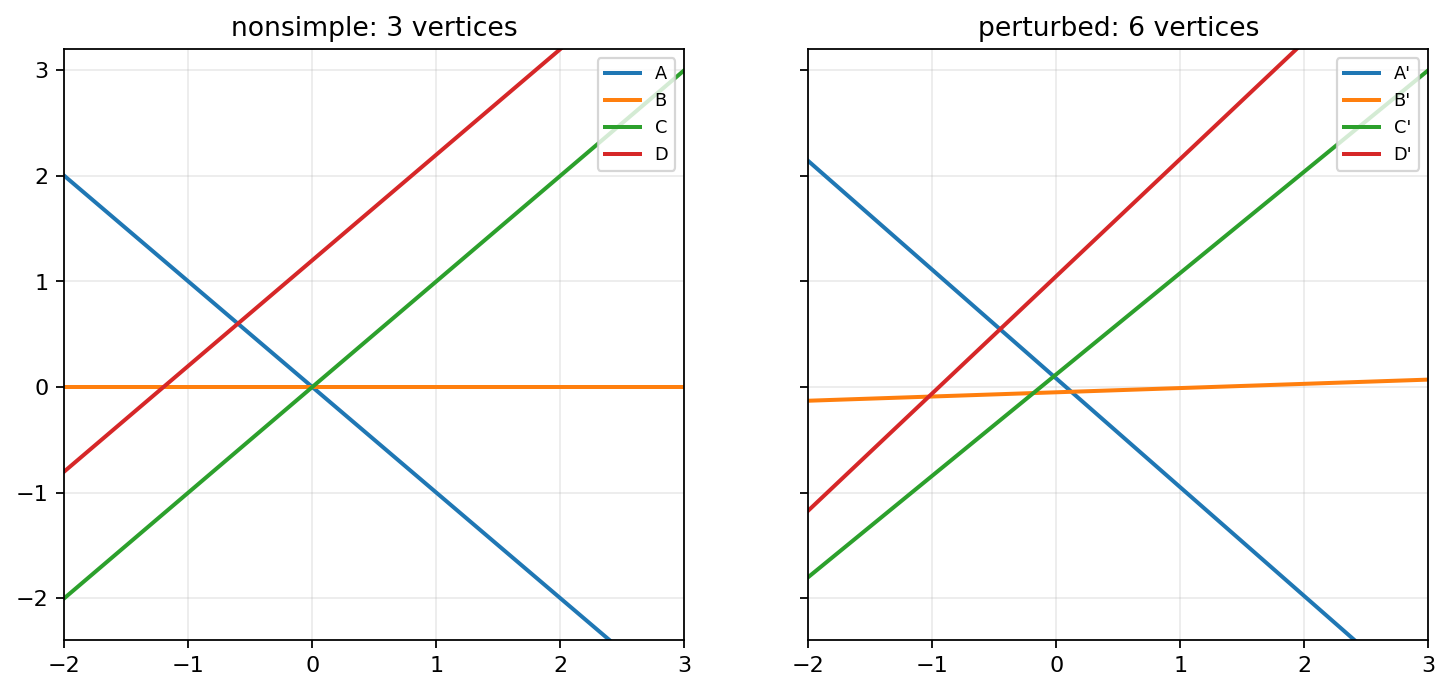

In [3]:
degenerate = [
    {"name": "A", "m": -1.0, "b": 0.0},
    {"name": "B", "m": 0.0, "b": 0.0},
    {"name": "C", "m": 1.0, "b": 0.0},
    {"name": "D", "m": 1.0, "b": 1.2},  # parallel to C
]
perturbed = [
    {"name": "A'", "m": -1.03, "b": 0.08},
    {"name": "B'", "m": 0.04, "b": -0.05},
    {"name": "C'", "m": 0.96, "b": 0.12},
    {"name": "D'", "m": 1.11, "b": 1.05},
]

def vertex_count_for(line_set):
    pts = []
    for i, j in combinations(range(len(line_set)), 2):
        if abs(line_set[i]["m"] - line_set[j]["m"]) < 1e-12:
            continue
        p = intersect(line_set[i], line_set[j])
        pts.append((round(float(p[0]), 6), round(float(p[1]), 6)))
    return len(set(pts)), pts

deg_count, deg_pts = vertex_count_for(degenerate)
pert_count, pert_pts = vertex_count_for(perturbed)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)
for ax, line_set, title in [(axes[0], degenerate, f"nonsimple: {deg_count} vertices"), (axes[1], perturbed, f"perturbed: {pert_count} vertices")]:
    for line in line_set:
        ax.plot(xx, line["m"]*xx + line["b"], linewidth=1.8, label=line["name"])
    ax.set_xlim(-2, 3); ax.set_ylim(-2.4, 3.2)
    ax.grid(True, alpha=0.25)
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right")
deg_fig_path = save_matplotlib(fig, FIGURES / "degeneracy-perturbation.png")
plt.close(fig)
deg_report_path = save_json({
    "degenerate_vertex_count": deg_count,
    "perturbed_vertex_count": pert_count,
    "simple_max_for_four_lines": math.comb(4, 2),
    "checks": {
        "perturbation_increases_vertices": pert_count > deg_count,
        "perturbed_reaches_simple_maximum": pert_count == math.comb(4, 2),
    },
}, CHECKS / "degeneracy-perturbation.json")
display_artifact(deg_fig_path, width=900)


## Zone Theorem and Incremental Construction

The zone of a line is the set of cells it crosses in an existing arrangement. The theorem's significance is algorithmic: inserting a line only requires walking its zone, and the total number of boundary edges of those crossed cells is linear in the number of existing lines. The source gives the explicit upper bound `Zn < 6n`. The plotted example uses the horizontal line `h`; the ledger counts a simple traversal proxy and compares it to the theorem bound.


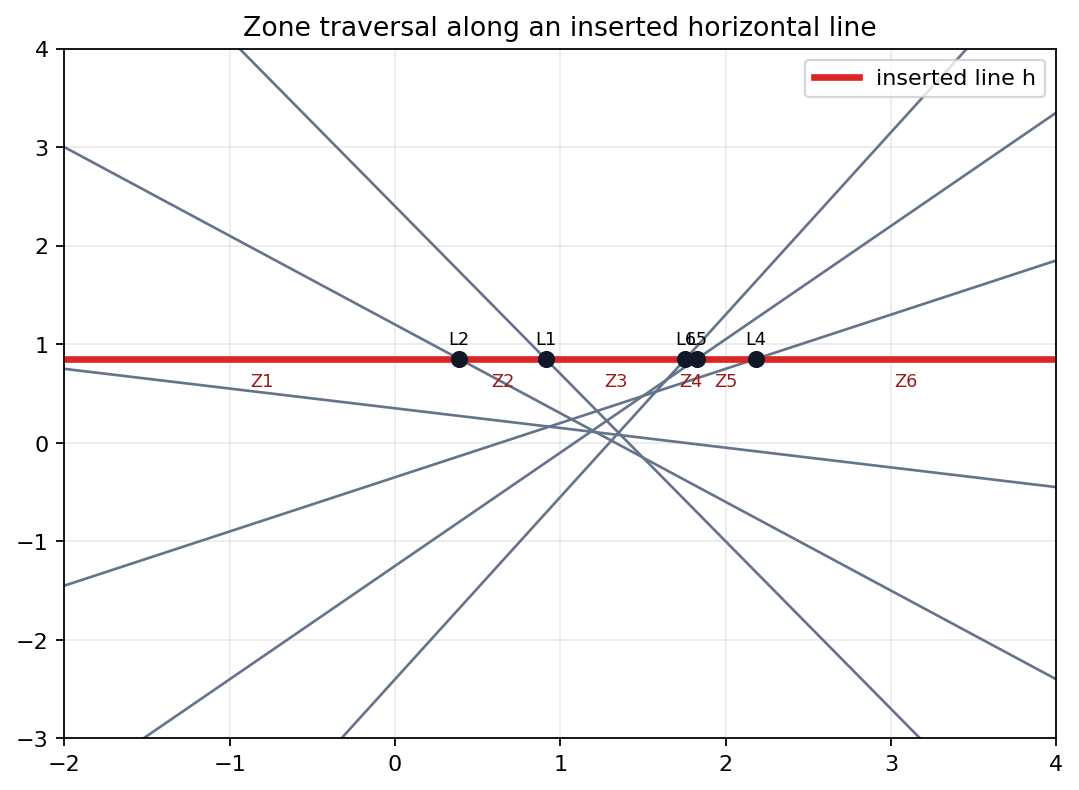

In [4]:
h_y = 0.85
crossings = sorted([(float((h_y - line["b"]) / line["m"]), line["name"]) for line in lines if abs(line["m"]) > 1e-12])
zone_cells = len(crossings) + 1
zone_edge_proxy = 2 * zone_cells + max(0, len(crossings) - 1)  # visible traversal ledger, not a full planar-subdivision count
zone_bound = 6 * n

fig, ax = plt.subplots(figsize=(8.0, 5.6))
for line in lines:
    ax.plot(xx, line["m"]*xx + line["b"], color="#64748b", linewidth=1.2)
ax.axhline(h_y, color="#dc2626", linewidth=3, label="inserted line h")
for k, (xhit, lname) in enumerate(crossings):
    if -2.0 <= xhit <= 4.0:
        ax.scatter(xhit, h_y, color="#111827", s=45, zorder=5)
        ax.text(xhit, h_y+0.15, lname, ha="center", fontsize=8)
for a, b, label in zip([-2.0]+[c[0] for c in crossings], [c[0] for c in crossings]+[4.0], range(zone_cells)):
    mid = (max(a, -2.0) + min(b, 4.0))/2
    if -2.0 < mid < 4.0:
        ax.text(mid, h_y-0.28, f"Z{label}", ha="center", color="#991b1b", fontsize=8)
ax.set_xlim(-2.0, 4.0); ax.set_ylim(-3.0, 4.0)
ax.set_title("Zone traversal along an inserted horizontal line")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
zone_fig_path = save_matplotlib(fig, FIGURES / "zone-traversal-bound.png")
plt.close(fig)
zone_report_path = save_json({
    "inserted_line": "h: y=0.85",
    "crossing_order": [{"x": x, "line": name} for x, name in crossings],
    "zone_cells_crossed": zone_cells,
    "zone_edge_proxy": zone_edge_proxy,
    "theorem_bound_6n": zone_bound,
    "checks": {
        "zone_ledger_below_six_n": zone_edge_proxy < zone_bound,
        "zone_cells_equal_n_plus_one_for_transversal_line": zone_cells == n + 1,
    },
}, CHECKS / "zone-traversal-bound.json")
display_artifact(zone_fig_path, width=760)


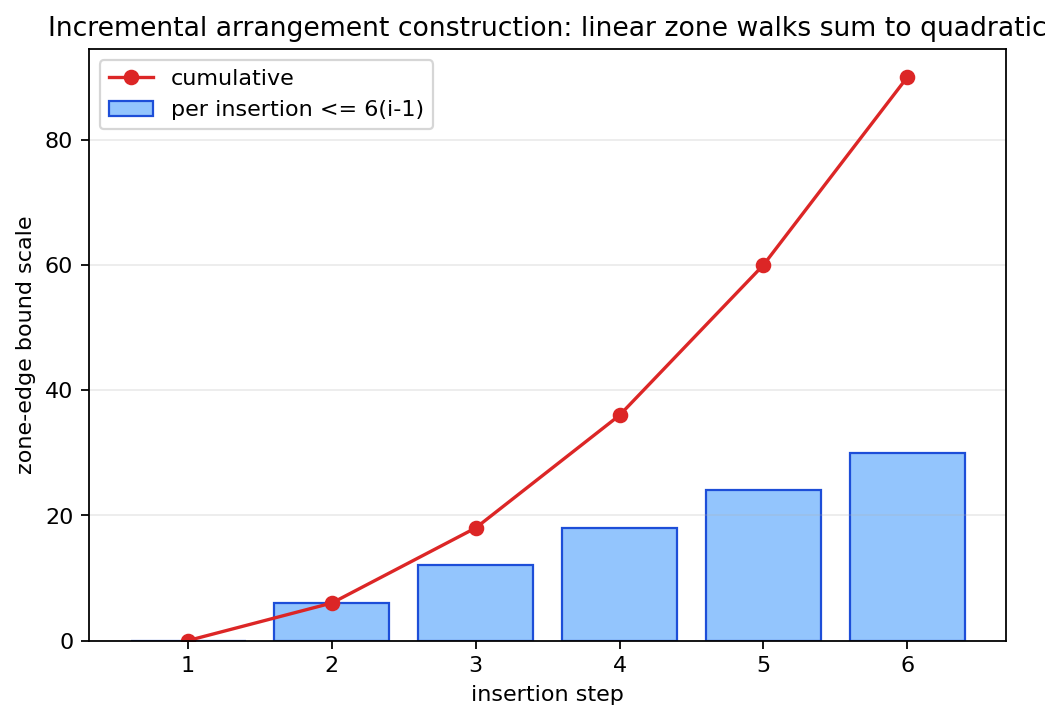

In [5]:
incremental_rows = []
running = 0
for i in range(1, n+1):
    existing = i - 1
    zone_limit = 6 * existing
    running += zone_limit
    incremental_rows.append({"inserted_line": i, "existing_lines_before_insert": existing, "zone_bound": zone_limit, "cumulative_bound": running})
incremental_table_path = save_csv(incremental_rows, TABLES / "incremental-zone-costs.csv")
fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.bar([row["inserted_line"] for row in incremental_rows], [row["zone_bound"] for row in incremental_rows], color="#93c5fd", edgecolor="#1d4ed8", label="per insertion <= 6(i-1)")
ax.plot([row["inserted_line"] for row in incremental_rows], [row["cumulative_bound"] for row in incremental_rows], color="#dc2626", marker="o", label="cumulative")
ax.set_xlabel("insertion step")
ax.set_ylabel("zone-edge bound scale")
ax.set_title("Incremental arrangement construction: linear zone walks sum to quadratic")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
incremental_fig_path = save_matplotlib(fig, FIGURES / "incremental-zone-costs.png")
plt.close(fig)
incremental_report_path = save_json({
    "rows": incremental_rows,
    "checks": {
        "incremental_total_is_quadratic_scale": running == 6 * n * (n-1) // 2,
        "last_step_has_linear_bound": incremental_rows[-1]["zone_bound"] == 6 * (n-1),
    },
}, CHECKS / "incremental-zone-costs.json")
display_artifact(incremental_fig_path, width=720)


## Duality, Median Levels, and Ham-Sandwich Cuts

The point-line duality used in the chapter maps a point `(a,b)` to the line `y = ax - b`. For an odd set of points, bisectors correspond to the median level of the dual arrangement: points on that level have the same number of dual lines above and below. If two point sets are linearly separated, one median level is increasing and the other decreasing in the source's setup, so they meet once; the dual of that intersection is a simultaneous bisector, a ham-sandwich cut.


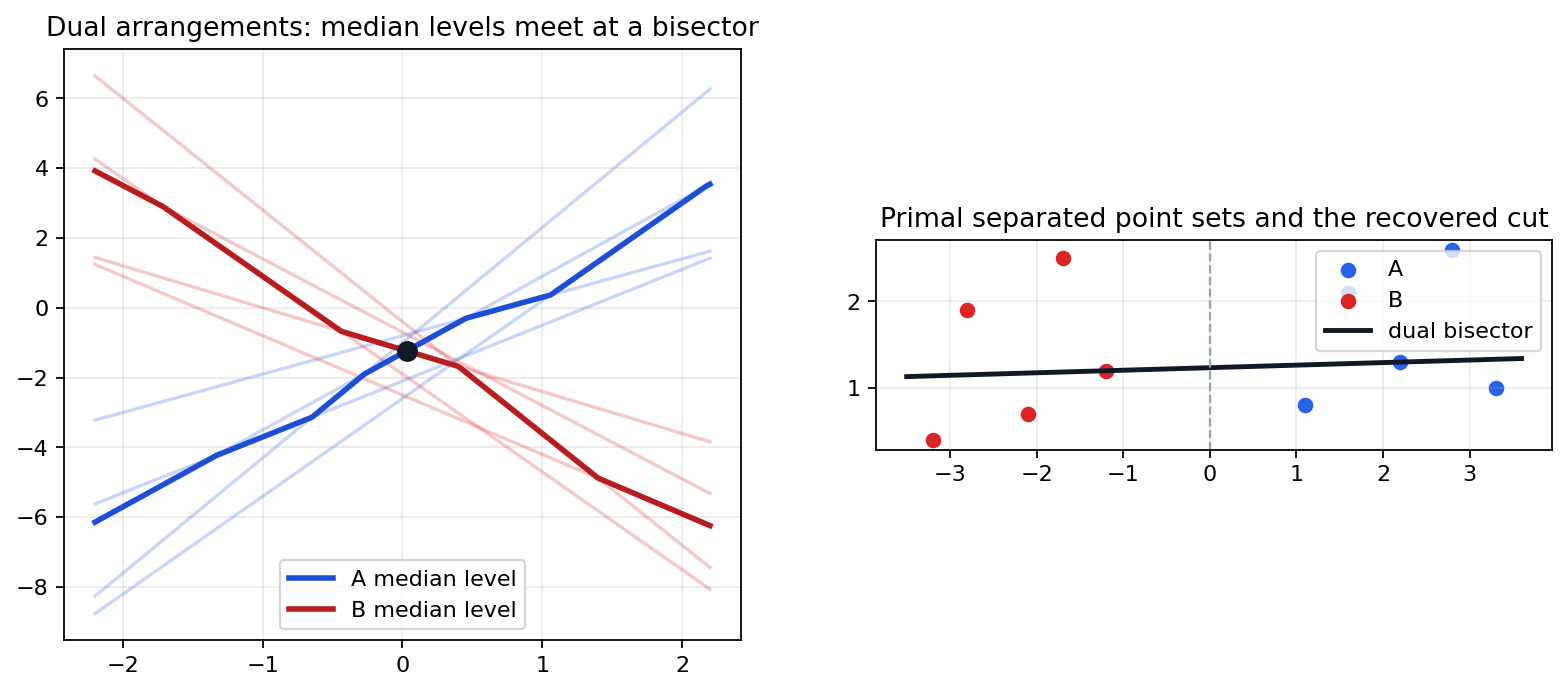

In [6]:
A_pts = np.array([[1.1, 0.8], [1.6, 2.1], [2.2, 1.3], [2.8, 2.6], [3.3, 1.0]], float)
B_pts = np.array([[-1.2, 1.2], [-1.7, 2.5], [-2.1, 0.7], [-2.8, 1.9], [-3.2, 0.4]], float)
xs = np.linspace(-2.2, 2.2, 401)

def dual_values(points, xs):
    return np.vstack([p[0] * xs - p[1] for p in points])

def median_level(vals):
    return np.median(vals, axis=0)
A_vals, B_vals = dual_values(A_pts, xs), dual_values(B_pts, xs)
A_med, B_med = median_level(A_vals), median_level(B_vals)
diff = A_med - B_med
sign_changes = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]
if len(sign_changes):
    k = sign_changes[0]
    t = abs(diff[k]) / (abs(diff[k]) + abs(diff[k+1]))
    x_cross = xs[k] * (1-t) + xs[k+1] * t
    y_cross = A_med[k] * (1-t) + A_med[k+1] * t
else:
    x_cross = float(xs[np.argmin(abs(diff))]); y_cross = float(A_med[np.argmin(abs(diff))])
# Dual point (u,v) maps back to primal line y = u*x - v.
ham_sandwich_line = {"slope": float(x_cross), "intercept": float(-y_cross)}

def side_counts(points, slope, intercept):
    vals = points[:,1] - (slope*points[:,0] + intercept)
    return {"above": int(np.sum(vals > 1e-8)), "below": int(np.sum(vals < -1e-8)), "on": int(np.sum(abs(vals) <= 1e-8))}
A_counts = side_counts(A_pts, ham_sandwich_line["slope"], ham_sandwich_line["intercept"])
B_counts = side_counts(B_pts, ham_sandwich_line["slope"], ham_sandwich_line["intercept"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
for row in A_vals:
    ax.plot(xs, row, color="#2563eb", alpha=0.25)
for row in B_vals:
    ax.plot(xs, row, color="#dc2626", alpha=0.25)
ax.plot(xs, A_med, color="#1d4ed8", linewidth=2.5, label="A median level")
ax.plot(xs, B_med, color="#b91c1c", linewidth=2.5, label="B median level")
ax.scatter(x_cross, y_cross, color="#111827", s=70, zorder=5)
ax.set_title("Dual arrangements: median levels meet at a bisector")
ax.grid(True, alpha=0.25); ax.legend()
ax = axes[1]
ax.scatter(A_pts[:,0], A_pts[:,1], color="#2563eb", label="A")
ax.scatter(B_pts[:,0], B_pts[:,1], color="#dc2626", label="B")
xxp = np.linspace(-3.5, 3.6, 100)
ax.plot(xxp, ham_sandwich_line["slope"]*xxp + ham_sandwich_line["intercept"], color="#111827", linewidth=2.2, label="dual bisector")
ax.axvline(0, color="#94a3b8", linestyle="--", linewidth=1)
ax.set_aspect("equal")
ax.grid(True, alpha=0.25); ax.legend()
ax.set_title("Primal separated point sets and the recovered cut")
duality_fig_path = save_matplotlib(fig, FIGURES / "duality-median-levels.png")
plt.close(fig)
duality_report_path = save_json({
    "dual_intersection": {"x": float(x_cross), "y": float(y_cross)},
    "ham_sandwich_line": ham_sandwich_line,
    "A_side_counts": A_counts,
    "B_side_counts": B_counts,
    "checks": {
        "median_levels_intersect_once_in_window": len(sign_changes) == 1,
        "cut_bisects_A_with_odd_count": max(A_counts["above"], A_counts["below"]) <= len(A_pts)//2,
        "cut_bisects_B_with_odd_count": max(B_counts["above"], B_counts["below"]) <= len(B_pts)//2,
    },
}, CHECKS / "duality-median-levels.json")
display_artifact(duality_fig_path, width=940)


## Application Map

The source chapter gives arrangements as a common framework rather than a single-purpose data structure. Visibility graphs use arrangements to reduce a cubic endpoint-visibility test to quadratic scale. Hidden-surface removal uses arrangements and topological sweep to achieve worst-case optimal quadratic behavior under the stated assumptions. Aspect graphs and smallest polytope shadows use arrangements of planes. Ham-sandwich cuts and red-blue matching use dual levels. Centerpoint and minimum-area-triangle exercises ask the reader to reinterpret geometric claims as level or dual-arrangement searches.


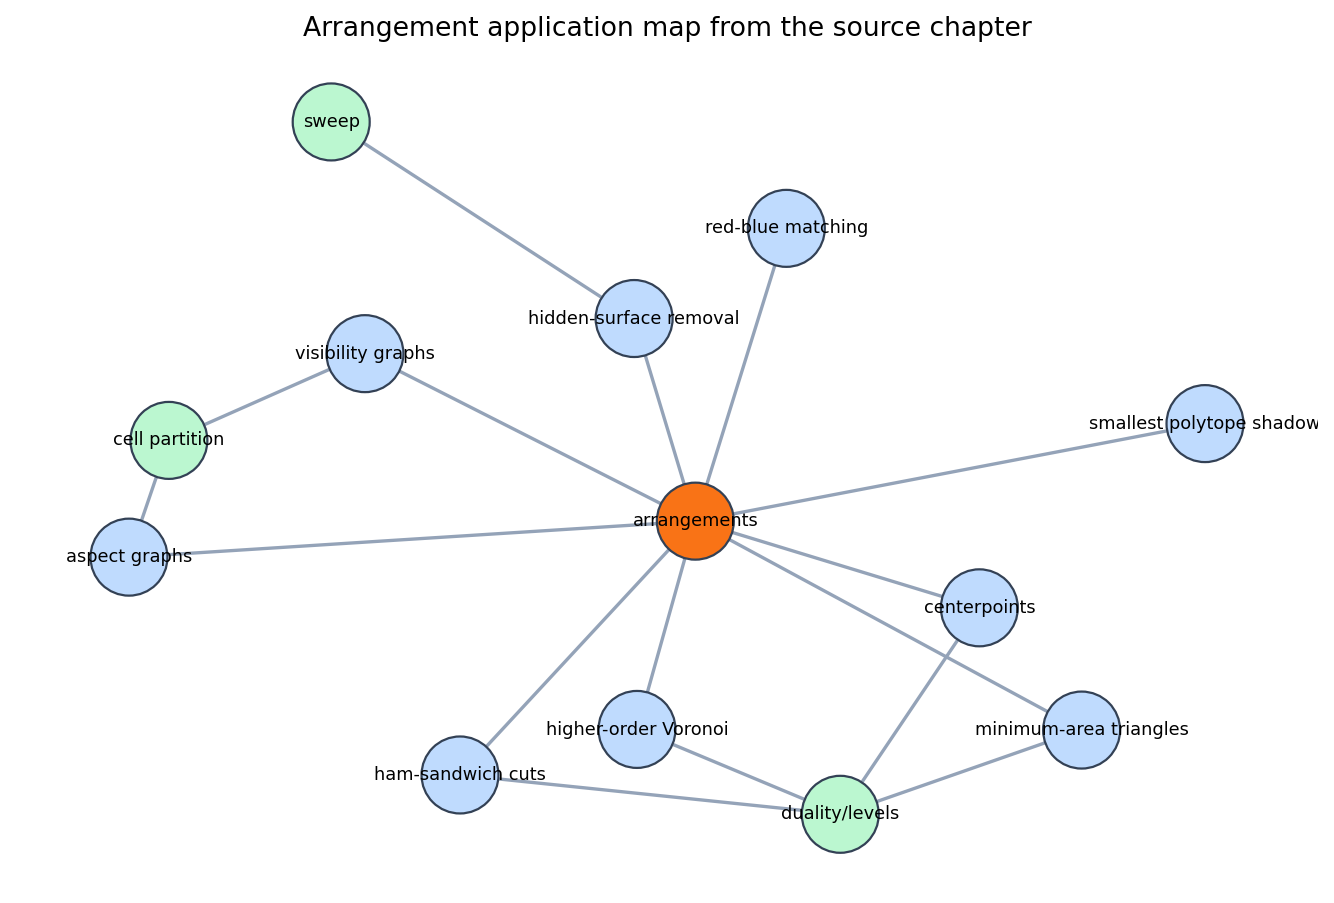

In [7]:
application_rows = [
    {"application": "visibility graphs", "arrangement_role": "partition sight lines and obstacle endpoints", "source_section": "6.1 / 6.7"},
    {"application": "hidden-surface removal", "arrangement_role": "project edges, sweep arrangement cells", "source_section": "6.7.2"},
    {"application": "aspect graphs", "arrangement_role": "view-space partition by face planes", "source_section": "6.7.3"},
    {"application": "smallest polytope shadow", "arrangement_role": "directions represented by line arrangement on a plane", "source_section": "6.7.4"},
    {"application": "ham-sandwich cuts", "arrangement_role": "median levels in dual arrangements", "source_section": "6.7.6"},
    {"application": "red-blue matching", "arrangement_role": "recursive ham-sandwich separation", "source_section": "6.7.6"},
    {"application": "higher-order Voronoi", "arrangement_role": "levels encode kth-nearest structure", "source_section": "6.6"},
    {"application": "centerpoints", "arrangement_role": "depth and levels in halfplane ranges", "source_section": "6.8"},
    {"application": "minimum-area triangles", "arrangement_role": "dual nearest-line relationship", "source_section": "6.8"},
]
application_table_path = save_csv(application_rows, TABLES / "arrangement-application-map.csv")
Agraph = nx.Graph()
Agraph.add_node("arrangements")
for row in application_rows:
    Agraph.add_edge("arrangements", row["application"])
    if "dual" in row["arrangement_role"] or "levels" in row["arrangement_role"]:
        Agraph.add_edge(row["application"], "duality/levels")
    if "sweep" in row["arrangement_role"]:
        Agraph.add_edge(row["application"], "sweep")
    if "partition" in row["arrangement_role"]:
        Agraph.add_edge(row["application"], "cell partition")
pos = nx.spring_layout(Agraph, seed=31, k=0.85)
fig, ax = plt.subplots(figsize=(10.5, 6.8))
colors = ["#f97316" if n == "arrangements" else "#bfdbfe" if n in {r["application"] for r in application_rows} else "#bbf7d0" for n in Agraph.nodes]
nx.draw_networkx_nodes(Agraph, pos, node_color=colors, edgecolors="#334155", node_size=1200, ax=ax)
nx.draw_networkx_edges(Agraph, pos, edge_color="#94a3b8", width=1.5, ax=ax)
nx.draw_networkx_labels(Agraph, pos, font_size=8, ax=ax)
ax.set_title("Arrangement application map from the source chapter")
ax.axis("off")
application_fig_path = save_matplotlib(fig, FIGURES / "arrangement-application-map.png")
plt.close(fig)
application_report_path = save_json({
    "applications": application_rows,
    "checks": {
        "application_map_covers_source_examples": len(application_rows) >= 8,
        "application_map_mentions_duality_and_sweep": any("dual" in row["arrangement_role"] for row in application_rows) and any("sweep" in row["arrangement_role"] for row in application_rows),
    },
}, CHECKS / "arrangement-application-map.json")
display_artifact(application_fig_path, width=880)


## Applied Lab

Change one line in the simple arrangement so it becomes parallel to another line, then rerun the count cell. The vertex count should drop below `C(n,2)`. Move the inserted zone line `h`; the crossing order changes, but the linear bound remains. In the duality cell, move one point from the right set to the left side of the separating axis and watch the single-intersection behavior become less clean. Those experiments mirror the chapter's habit of stating simple-position assumptions first and then asking how algorithms survive degeneracy.


## Takeaways

Arrangements are a language for cutting space into cells. Their combinatorics are quadratic in the plane for lines, but the zone theorem says that one inserted line only sees linear complexity. That is why incremental construction works. Duality turns point problems into line-level problems, and levels turn bisectors, centerpoints, and higher-order nearest-neighbor structures into search problems. The applications are broad because the same partition of space can represent visibility, graphics, shadows, matching, and optimization.

The checks in this notebook make the abstract chapter inspectable: simple counts match formulas, perturbation increases degeneracy-reduced complexity, the zone ledger stays below `6n`, incremental zone bounds sum quadratically, median levels recover a bisector, and the application map covers the source examples.


In [8]:
# final_sanity
final_sanity = {
    "unit": UNIT_TITLE,
    "artifact_count": 14,
    "checks": {
        "simple_counts_match_formula": len(unique_vertices) == V_formula and E_formula == n*n and F_formula == V_formula+n+1,
        "perturbation_increases_vertices": pert_count > deg_count,
        "zone_ledger_below_six_n": zone_edge_proxy < zone_bound,
        "zone_cells_equal_n_plus_one_for_transversal_line": zone_cells == n + 1,
        "incremental_total_is_quadratic_scale": running == 6 * n * (n-1) // 2,
        "median_levels_intersect_once_in_window": len(sign_changes) == 1,
        "application_map_covers_source_examples": len(application_rows) >= 8,
    },
    "artifacts": [
        str(storyboard_path), str(routing_path), str(coverage_path), str(arrangement_fig_path), str(intersection_table_path), str(counts_report_path),
        str(deg_fig_path), str(deg_report_path), str(zone_fig_path), str(zone_report_path), str(incremental_table_path), str(incremental_fig_path), str(incremental_report_path),
        str(duality_fig_path), str(duality_report_path), str(application_table_path), str(application_fig_path), str(application_report_path),
    ],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final-sanity.json")
assert all(final_sanity["checks"].values()), json.dumps(final_sanity["checks"], indent=2)
assert_artifacts([Path(p) for p in final_sanity["artifacts"]] + [final_sanity_path], min_bytes=40)
print(json.dumps({"final_sanity": "passed", "checks": final_sanity["checks"]}, indent=2))


{
  "final_sanity": "passed",
  "checks": {
    "simple_counts_match_formula": true,
    "perturbation_increases_vertices": true,
    "zone_ledger_below_six_n": true,
    "zone_cells_equal_n_plus_one_for_transversal_line": true,
    "incremental_total_is_quadratic_scale": true,
    "median_levels_intersect_once_in_window": true,
    "application_map_covers_source_examples": true
  }
}
